In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Loading
data_url = 'https://raw.githubusercontent.com/KeithGalli/Pandas-Data-Science-Tasks/master/SalesAnalysis/Sales_Data/Sales_April_2019.csv'
sales_df = pd.read_csv(data_url)

print("My Initial Data:")
print(sales_df.head())

# Step 2: Cleaning Process
# Removing empty rows that might break my analysis
sales_df = sales_df.dropna(how='all')

# Fixing a common issue in this data where headers repeat in rows
sales_df = sales_df[sales_df['Order Date'].str[0:2] != 'Or']

sales_df['Quantity Ordered'] = pd.to_numeric(sales_df['Quantity Ordered'])
sales_df['Price Each'] = pd.to_numeric(sales_df['Price Each'])

sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])

# Step 3: Feature Engineering
sales_df['Total_Sales'] = sales_df['Quantity Ordered'] * sales_df['Price Each']

sales_df['Month'] = sales_df['Order Date'].dt.month

print("\nData is now clean and ready for analysis!")
sales_df.head()

My Initial Data:
  Order ID                     Product Quantity Ordered Price Each  \
0   176558        USB-C Charging Cable                2      11.95   
1      NaN                         NaN              NaN        NaN   
2   176559  Bose SoundSport Headphones                1      99.99   
3   176560                Google Phone                1        600   
4   176560            Wired Headphones                1      11.99   

       Order Date                      Purchase Address  
0  04/19/19 08:46          917 1st St, Dallas, TX 75001  
1             NaN                                   NaN  
2  04/07/19 22:30     682 Chestnut St, Boston, MA 02215  
3  04/12/19 14:38  669 Spruce St, Los Angeles, CA 90001  
4  04/12/19 14:38  669 Spruce St, Los Angeles, CA 90001  


/tmp/ipykernel_1011/3529076491.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])



Data is now clean and ready for analysis!


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Total_Sales,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4


In [2]:
# Step 3: Feature Engineering

# 1. Creating 'Total_Sales' column
# Since I have price and quantity, I multiply them to get the total revenue per order
sales_df['Total_Sales'] = sales_df['Quantity Ordered'] * sales_df['Price Each']

# 2. Extracting City name from Address
# The city is between the two commas in the address, so I will use .apply() to get it
def get_city(address):
    return address.split(",")[1].strip()

sales_df['City'] = sales_df['Purchase Address'].apply(lambda x: get_city(x))

# 3. Adding a Month column just in case I want to analyze trends later
sales_df['Month'] = sales_df['Order Date'].dt.month

print("Step 3 Complete: Total Sales and City columns are now added!")
sales_df.head()

Step 3 Complete: Total Sales and City columns are now added!


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Total_Sales,Month,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4,Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4,Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4,Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4,Los Angeles


/tmp/ipykernel_1011/3874138052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


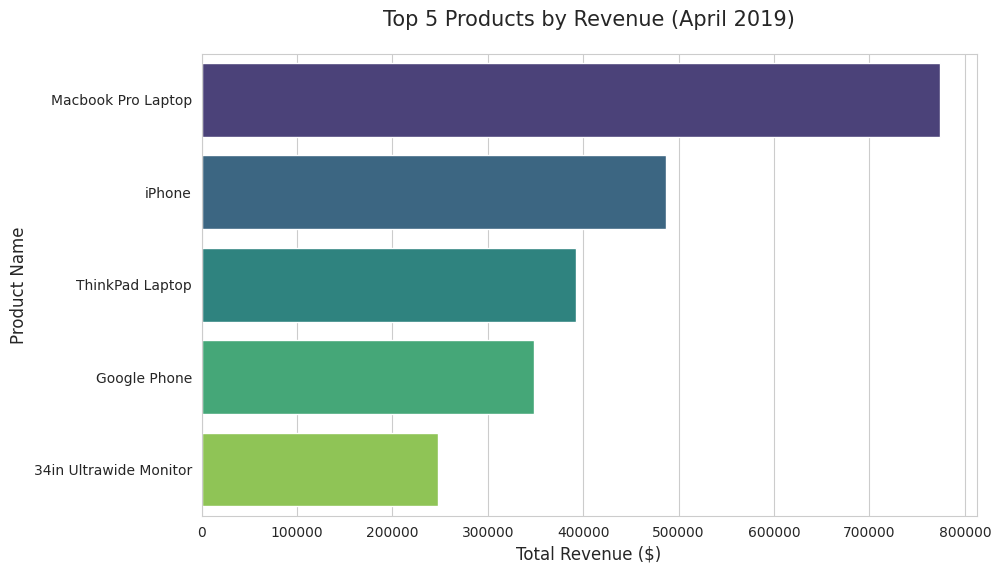

The chart shows that Google Phone and Bose Headphones are among the top earners!


In [3]:
# Step 4: Analyzing Best Selling Products
top_products = sales_df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(5)

# Step 5: Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creating the bar chart
plot = sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")

# Adding titles and labels
plt.title('Top 5 Products by Revenue (April 2019)', fontsize=15, pad=20)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Showing the chart
plt.show()

print("The chart shows that Google Phone and Bose Headphones are among the top earners!")

/tmp/ipykernel_1011/2416072934.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette="magma")


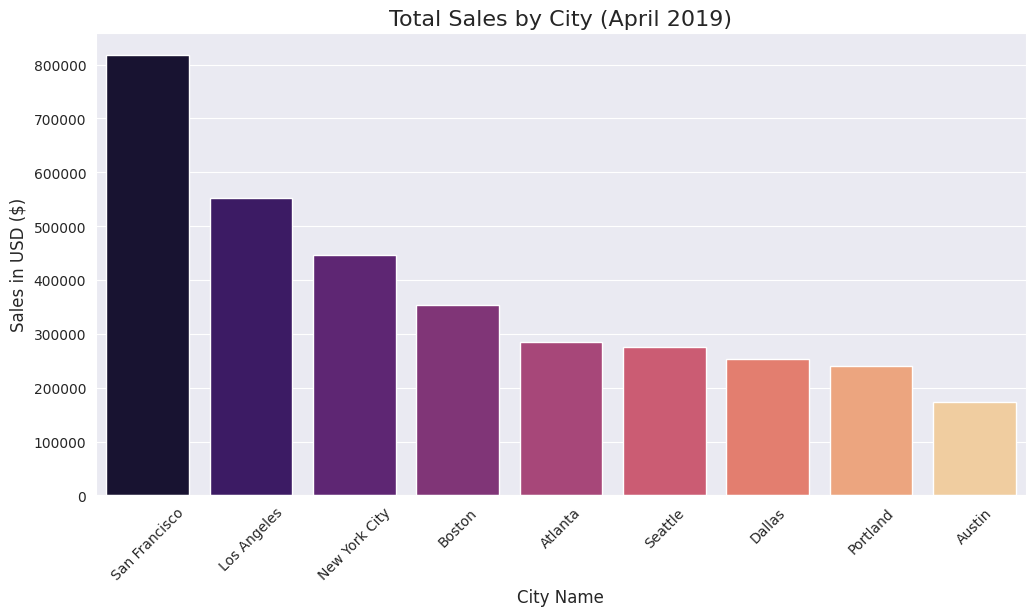

Success! The top city for April is San Francisco with $817,074.77 in sales.


In [4]:
# Step 6: Sales by City
city_sales = sales_df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid") # Changing style for variety

sns.barplot(x=city_sales.index, y=city_sales.values, palette="magma")

plt.title('Total Sales by City (April 2019)', fontsize=16)
plt.xlabel('City Name', fontsize=12)
plt.ylabel('Sales in USD ($)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

print(f"Success! The top city for April is {city_sales.index[0]} with ${city_sales.values[0]:,.2f} in sales.")